# Demystifying Model Behavior: From Simple Genetics to Complex Epistasis

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data. 

In the real world of genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost and hope it finds the true biological patterns. But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological mechanisms** governing the target trait (y). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (OLS) and Machine Learning (XGBoost + SHAP) uncover that truth across three increasingly realistic biological scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Mendelian World (Pure Main Effects)
* **The Reality:** The target y is driven by independent genes acting alone. These genes might have an additive effect (a straight line from 0 to 2), a dominant effect (having one copy is the same as having two), or a recessive effect (you need both copies to see the trait).
* **The Goal:** Establish a baseline. We will see how traditional OLS handles standard additive traits perfectly, but might slightly misinterpret purely dominant or recessive traits, while XGBoost captures the exact categorical steps. 

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Genes do not act in a vacuum; they interact with one another to influence the target (e.g., Gene A only turns on if Gene B is also present, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. OLS will struggle to see the gene-gene interaction without manual feature engineering, while XGBoost's tree structure will naturally map the combination. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary genetic sequencing or environmental data. We will watch our evaluation metrics (like R-squared and MSE) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact biological equations and categorical genotypes.
* **Baseline Modeling:** `statsmodels` (OLS) for traditional statistical significance and coefficient mapping.
* **Predictive Modeling:** `xgboost` to natively handle categorical data and capture non-linear step functions and complex interactions.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_2 import *

## simple linear combination test

### make example data 1

In [2]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (2.92 * Feature_8 [recessive]) + 
  (-1.58 * Feature_5 [additive]) + 
  (-1.52 * Feature_7 [additive]) + 
  (-0.98 * Feature_0 [additive]) + 
  (0.42 * Feature_9 [recessive]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.977
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                 1.707e+04
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:47:05   Log-Likelihood:                -352.51
No. Observations:                4000   AIC:                             727.0
Df Residuals:                    3989   BIC:                             796.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

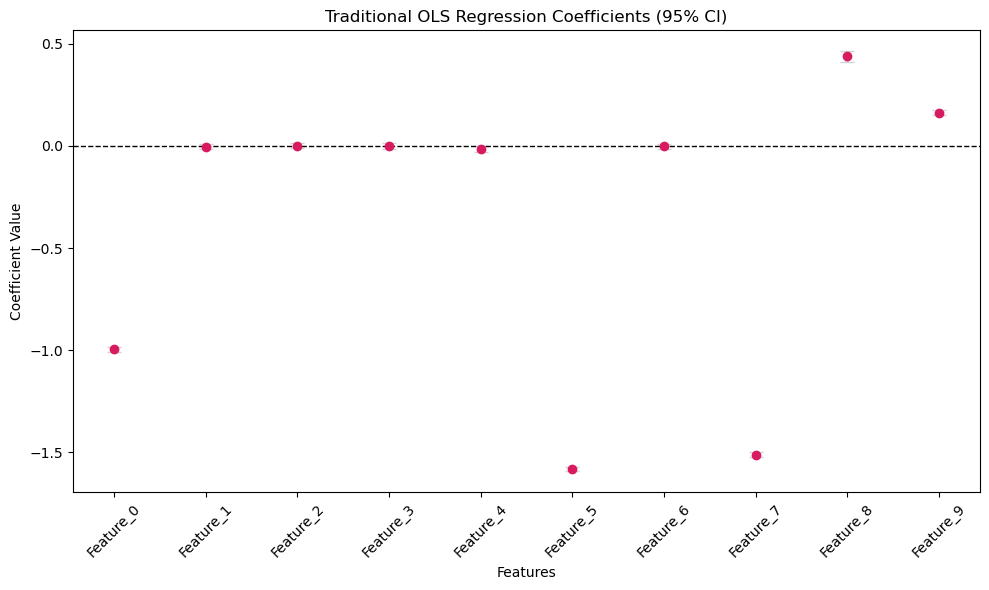

OLS Significant Features: {'Feature_0': {'pvalue': 0.0, 'coefficient': -0.9952057722051791}, 'Feature_5': {'pvalue': 0.0, 'coefficient': -1.5822670050421588}, 'Feature_7': {'pvalue': 0.0, 'coefficient': -1.51102938591804}, 'Feature_8': {'pvalue': 3.2103427115866233e-223, 'coefficient': 0.43819601271260805}, 'Feature_9': {'pvalue': 2.904323370618935e-157, 'coefficient': 0.162627585245321}, 'Feature_4': {'pvalue': 0.0329191197059538, 'coefficient': -0.015729040388939304}}


In [3]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 1

In [4]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9960
MSE: 0.0128



### look at XGBoost Native Importances

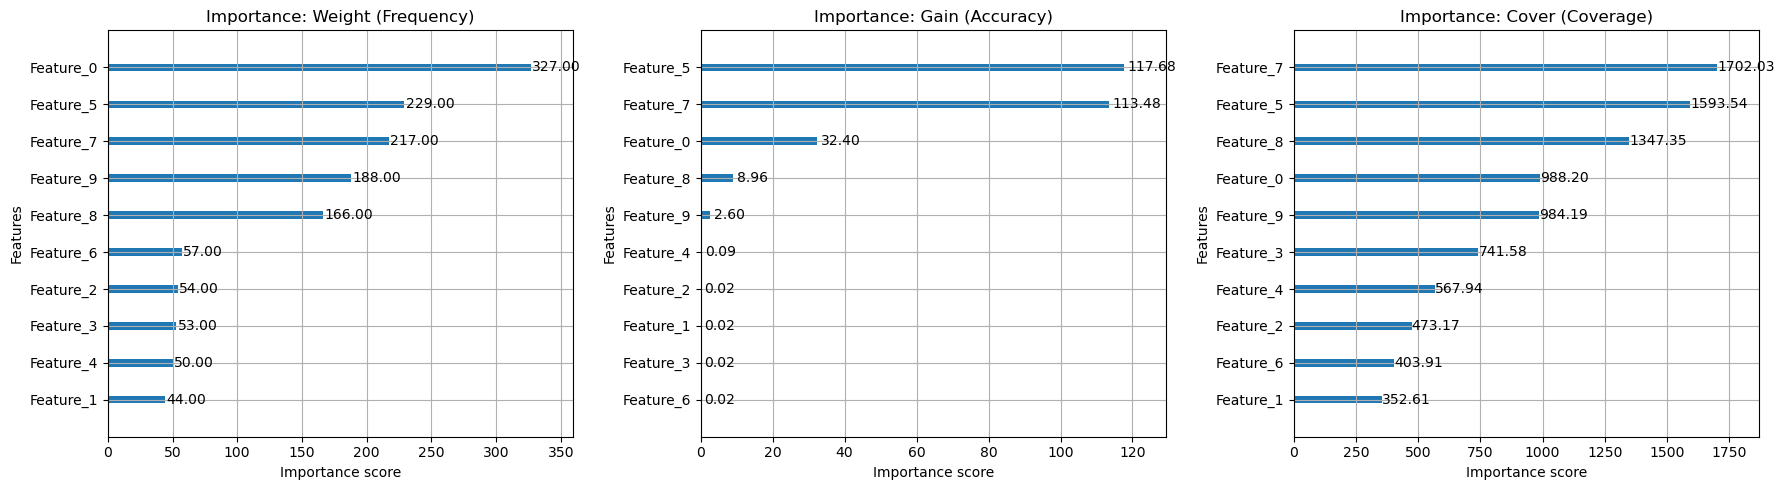

XGBoost Weight Importance: {'Feature_0': 327.0, 'Feature_1': 44.0, 'Feature_2': 54.0, 'Feature_3': 53.0, 'Feature_4': 50.0, 'Feature_5': 229.0, 'Feature_6': 57.0, 'Feature_7': 217.0, 'Feature_8': 166.0, 'Feature_9': 188.0}
XGBoost Gain Importance: {'Feature_0': 32.401241302490234, 'Feature_1': 0.020492402836680412, 'Feature_2': 0.024014094844460487, 'Feature_3': 0.01997561566531658, 'Feature_4': 0.09019026160240173, 'Feature_5': 117.67725372314453, 'Feature_6': 0.01924636773765087, 'Feature_7': 113.4778060913086, 'Feature_8': 8.959820747375488, 'Feature_9': 2.5972588062286377}
XGBoost Cover Importance: {'Feature_0': 988.2018432617188, 'Feature_1': 352.6136474609375, 'Feature_2': 473.1666564941406, 'Feature_3': 741.5848999023438, 'Feature_4': 567.9400024414062, 'Feature_5': 1593.54150390625, 'Feature_6': 403.91229248046875, 'Feature_7': 1702.0277099609375, 'Feature_8': 1347.349365234375, 'Feature_9': 984.1861572265625}


In [5]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [6]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

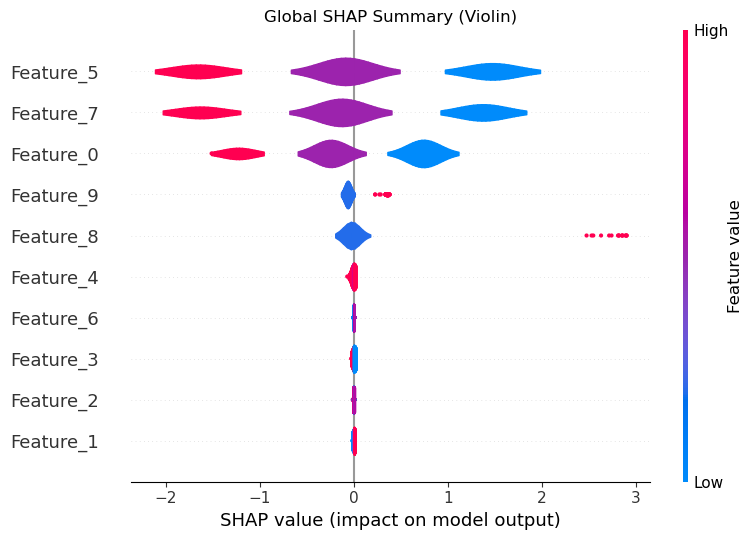

In [7]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


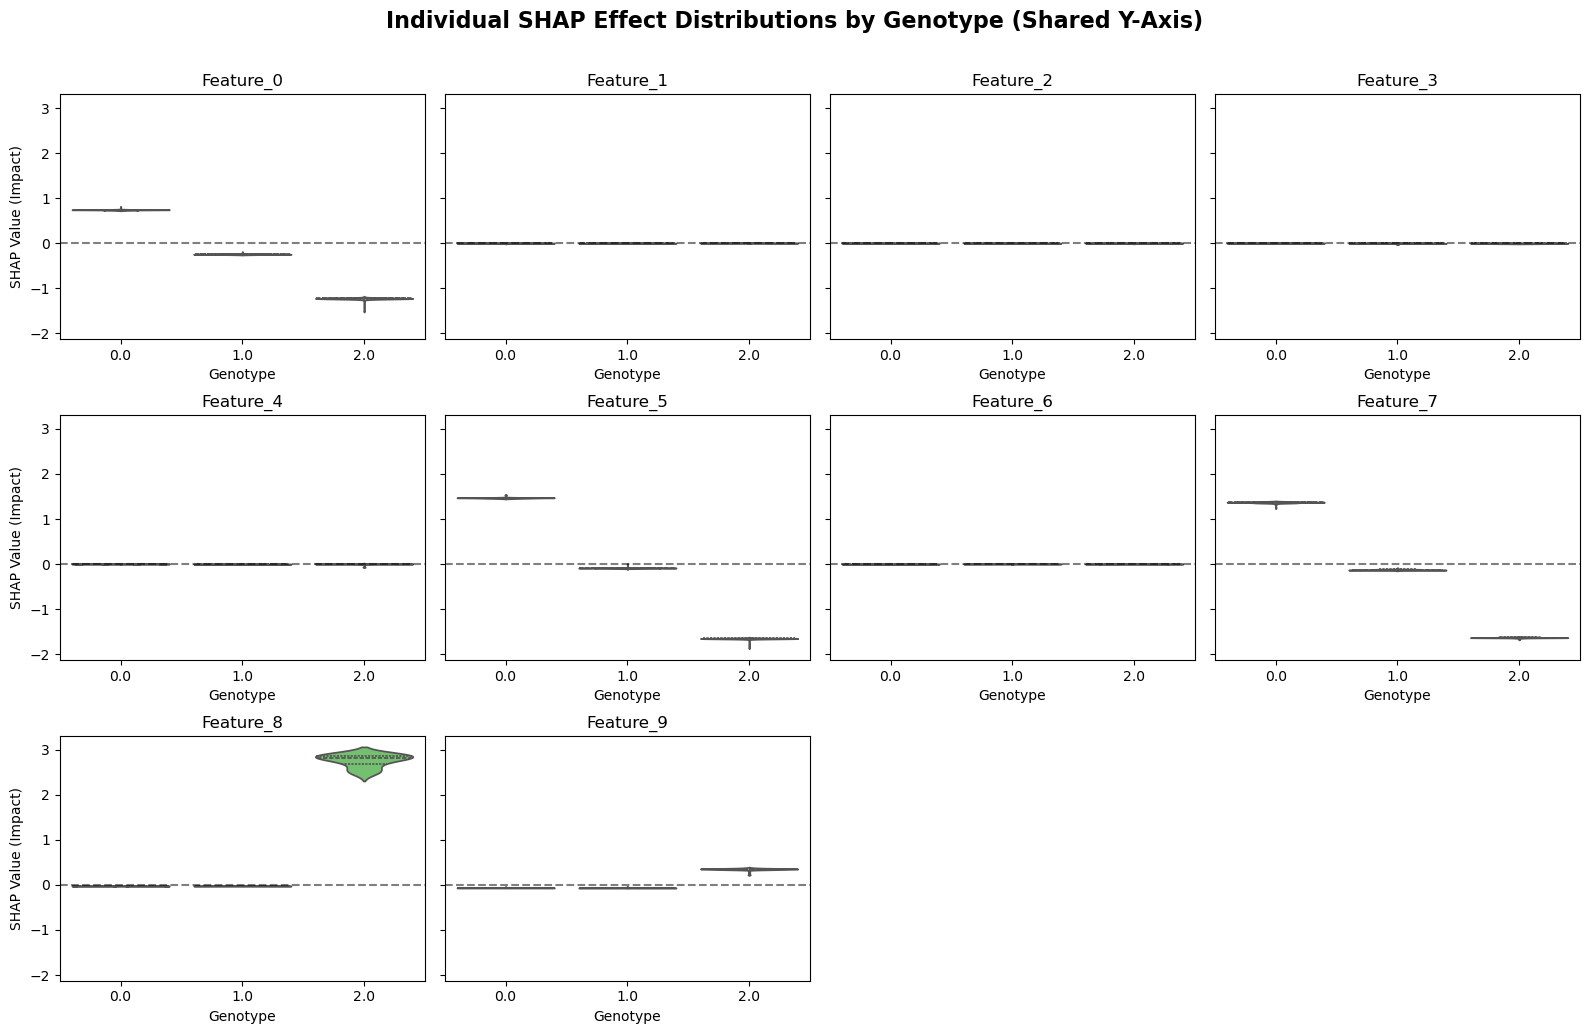

In [8]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


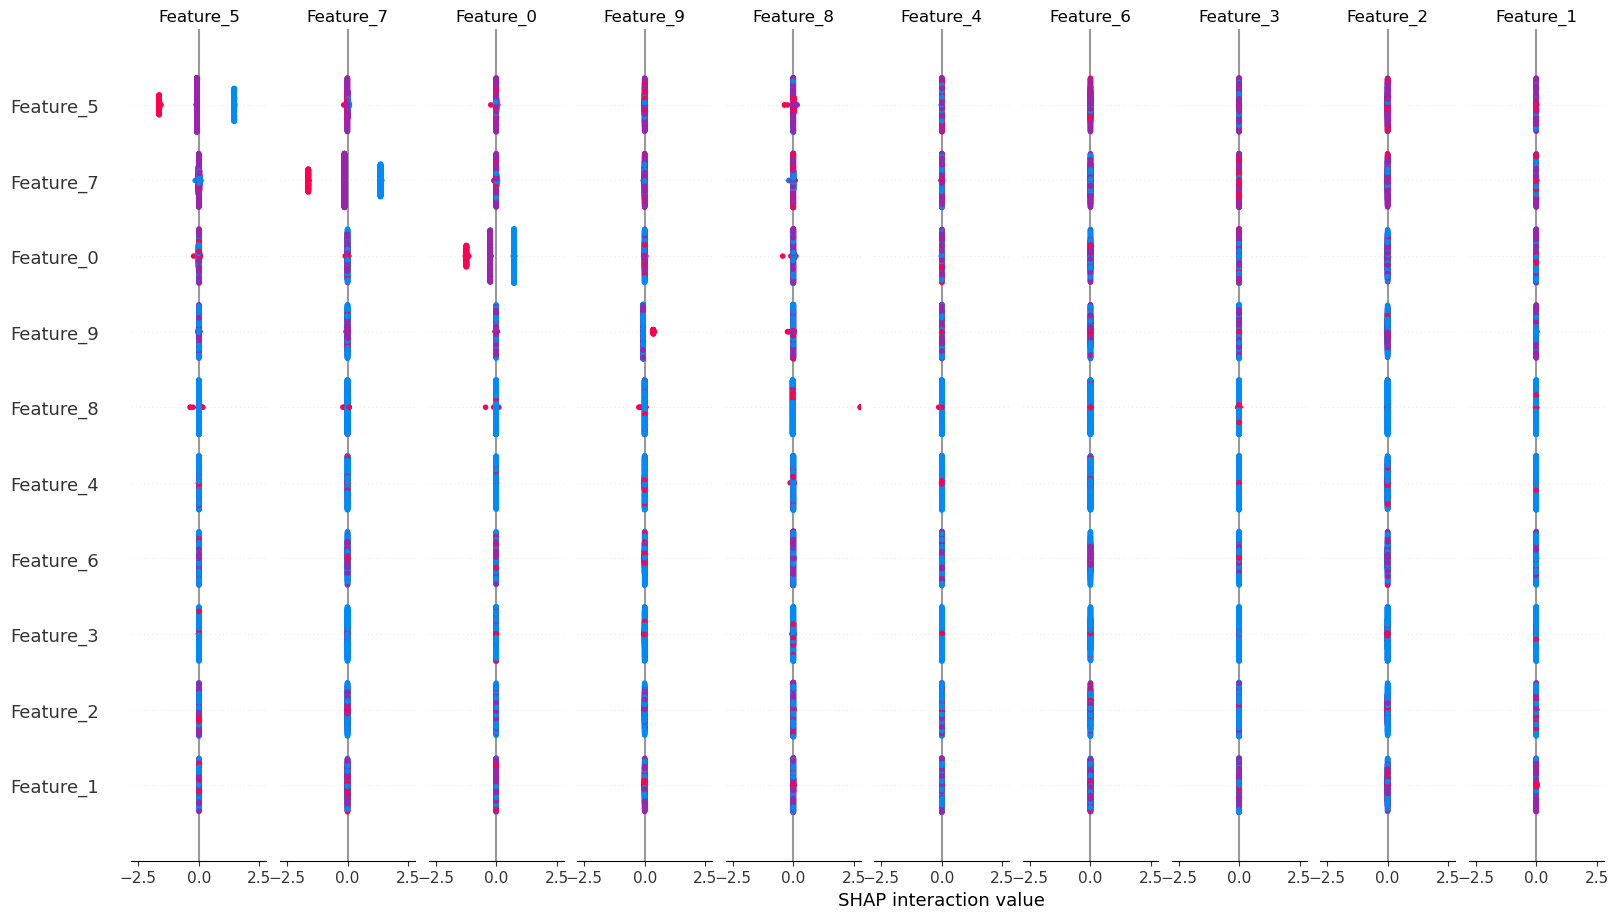


Strongest Interaction found by SHAP: Feature_5 & Feature_7
Plotting pure interaction effect for Feature_5 and Feature_7...


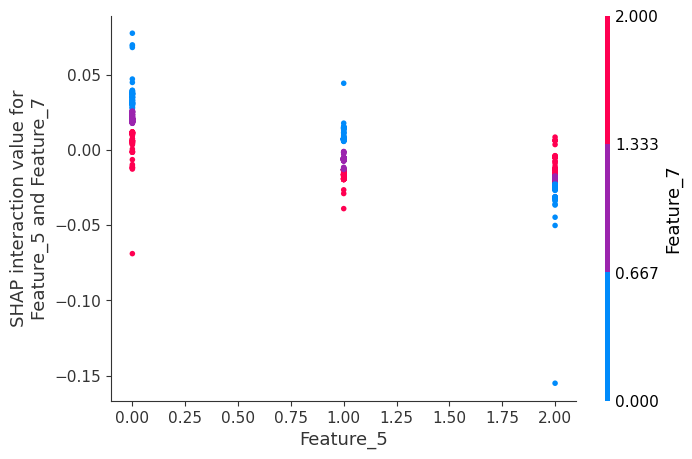


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_5 * Feature_7: 0.015880
  Feature_0 * Feature_5: 0.007540
  Feature_0 * Feature_7: 0.007355
  Feature_5 * Feature_8: 0.003666
  Feature_0 * Feature_9: 0.003071
  Feature_5 * Feature_9: 0.002397
  Feature_7 * Feature_9: 0.002244
  Feature_7 * Feature_8: 0.002227
  Feature_0 * Feature_4: 0.002099
  Feature_0 * Feature_8: 0.001958
-------------------------------------------------

Interaction Effects:
 {'Feature_5 * Feature_7': 0.015879860147833824, 'Feature_0 * Feature_5': 0.007539903745055199, 'Feature_0 * Feature_7': 0.0073547824285924435, 'Feature_5 * Feature_8': 0.003665851429104805, 'Feature_0 * Feature_9': 0.0030713125597685575, 'Feature_5 * Feature_9': 0.002396605908870697, 'Feature_7 * Feature_9': 0.0022443959023803473, 'Feature_7 * Feature_8': 0.0022265929728746414, 'Feature_0 * Feature_4': 0.002099375706166029, 'Feature_0 * Feature_8': 0.0019576267804950476, 'Feature_8 * Feature_9': 0.

In [9]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [10]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_5              0.857823     0.0    287   1.469946  0.010210  1.448737  1.464288     1.470526  1.474023  1.538471
Feature_5              0.857823     1.0    475  -0.088088  0.008605 -0.114449 -0.094185    -0.087883 -0.082420  0.006589
Feature_5              0.857823     2.0    238  -1.655856  0.021149 -1.865345 -1.656729    -1.653225 -1.651255 -1.635834
Feature_7              0.813109     0.0    296   1.369985  0.014940  1.239638  1.363357     1.371707  1.378342  1.392164
Feature_7              0.813109     1.0    493  -0.128928  0.008631 -0.150233 -0.134914    -0.132123 -0.120491 -0.083529
Feature_7              0.813109     2.0    211  -1.630484  0.008445 -1.677155 -1.635339    -1.633420 -1.624452 -1.611778
Feature_0              0.620825     0.0    415   0.740816  0.007217  0.723081  0.738182     0.74

## test for linear combination with some feature interactions

### make example data 2

In [11]:
# 1. Generate Data
X, _, y, visible_features, _ = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (-2.95 * Feature_5 [additive]) + 
  (-2.24 * Feature_0 [additive]) + 
  (-2.16 * Feature_2 [dominant]) + 
  (-1.95 * (Feature_1, Feature_9) [dominant_epistasis]) + 
  (1.73 * (Feature_5, Feature_9) [dominant_epistasis]) + 
  (1.58 * (Feature_1, Feature_5) [xor_interference]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.768
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     1317.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:47:12   Log-Likelihood:                -5910.1
No. Observations:                4000   AIC:                         1.184e+04
Df Residuals:                    3989   BIC:                         1.191e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

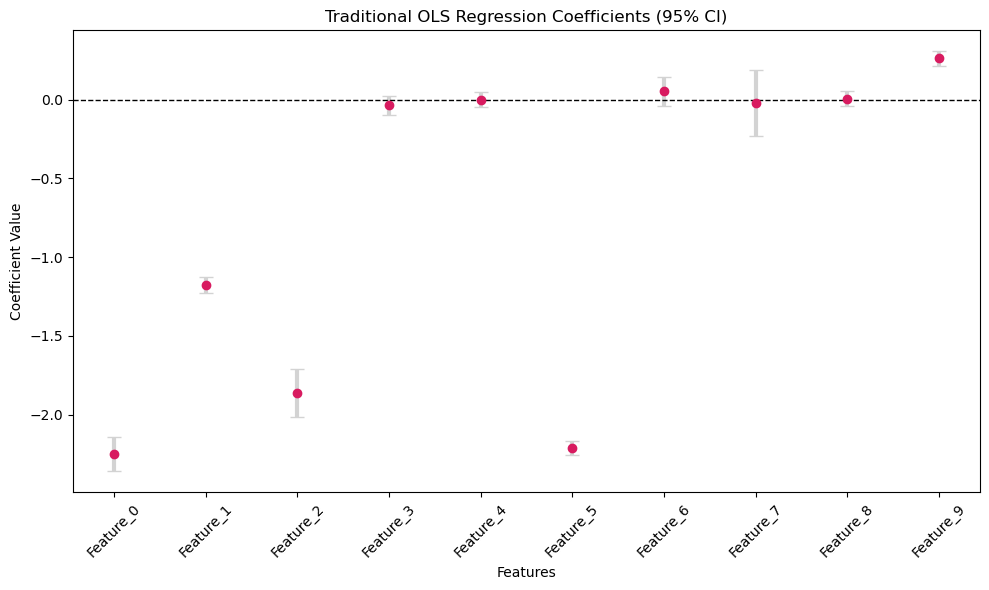

OLS Significant Features: {'Feature_1': {'pvalue': 0.0, 'coefficient': -1.177593149147238}, 'Feature_5': {'pvalue': 0.0, 'coefficient': -2.2128926743059445}, 'Feature_0': {'pvalue': 2.3528550975131633e-297, 'coefficient': -2.2506485248340153}, 'Feature_2': {'pvalue': 6.266440564854209e-119, 'coefficient': -1.8652288067524858}, 'Feature_9': {'pvalue': 1.001908264087742e-29, 'coefficient': 0.26224756564519824}}


In [12]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 2

In [13]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.9973
MSE: 0.0132



### look at XGBoost Native Importances

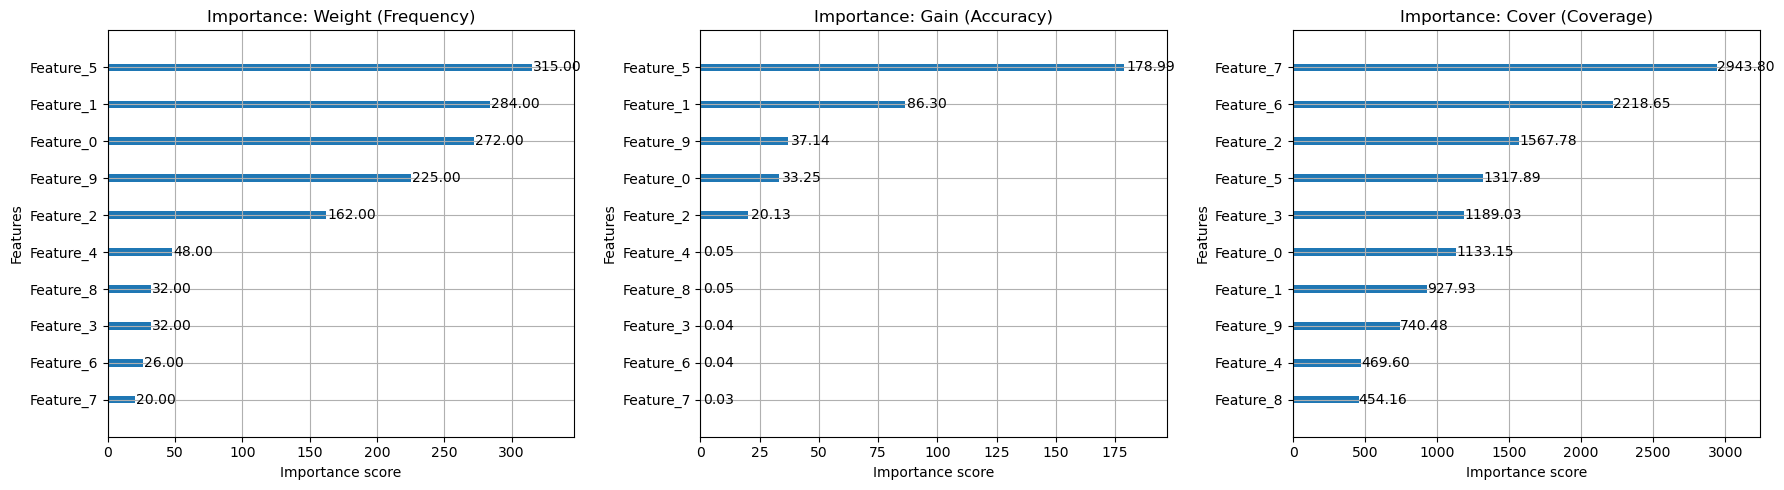

XGBoost Weight Importance: {'Feature_0': 272.0, 'Feature_1': 284.0, 'Feature_2': 162.0, 'Feature_3': 32.0, 'Feature_4': 48.0, 'Feature_5': 315.0, 'Feature_6': 26.0, 'Feature_7': 20.0, 'Feature_8': 32.0, 'Feature_9': 225.0}
XGBoost Gain Importance: {'Feature_0': 33.24820327758789, 'Feature_1': 86.2989501953125, 'Feature_2': 20.126972198486328, 'Feature_3': 0.04291970282793045, 'Feature_4': 0.04937467351555824, 'Feature_5': 178.9944305419922, 'Feature_6': 0.037957239896059036, 'Feature_7': 0.026715975254774094, 'Feature_8': 0.048507459461688995, 'Feature_9': 37.14384841918945}
XGBoost Cover Importance: {'Feature_0': 1133.1544189453125, 'Feature_1': 927.9260864257812, 'Feature_2': 1567.77783203125, 'Feature_3': 1189.03125, 'Feature_4': 469.6041564941406, 'Feature_5': 1317.888916015625, 'Feature_6': 2218.65380859375, 'Feature_7': 2943.800048828125, 'Feature_8': 454.15625, 'Feature_9': 740.4755859375}


In [14]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [15]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

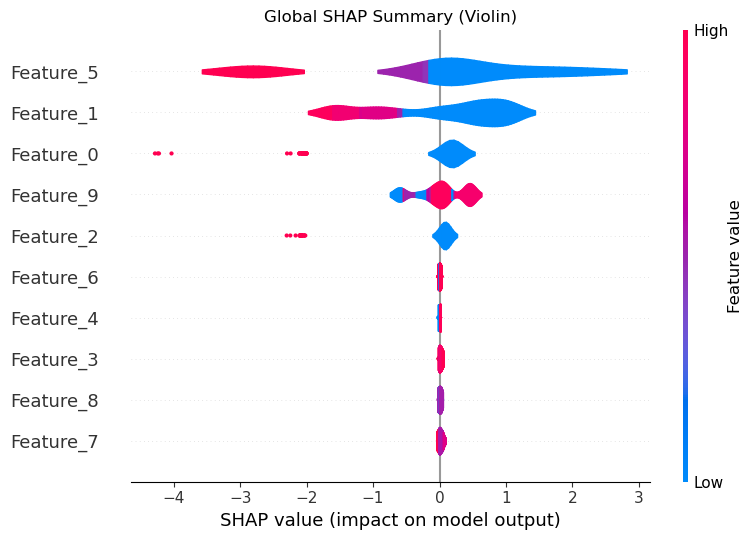

In [16]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


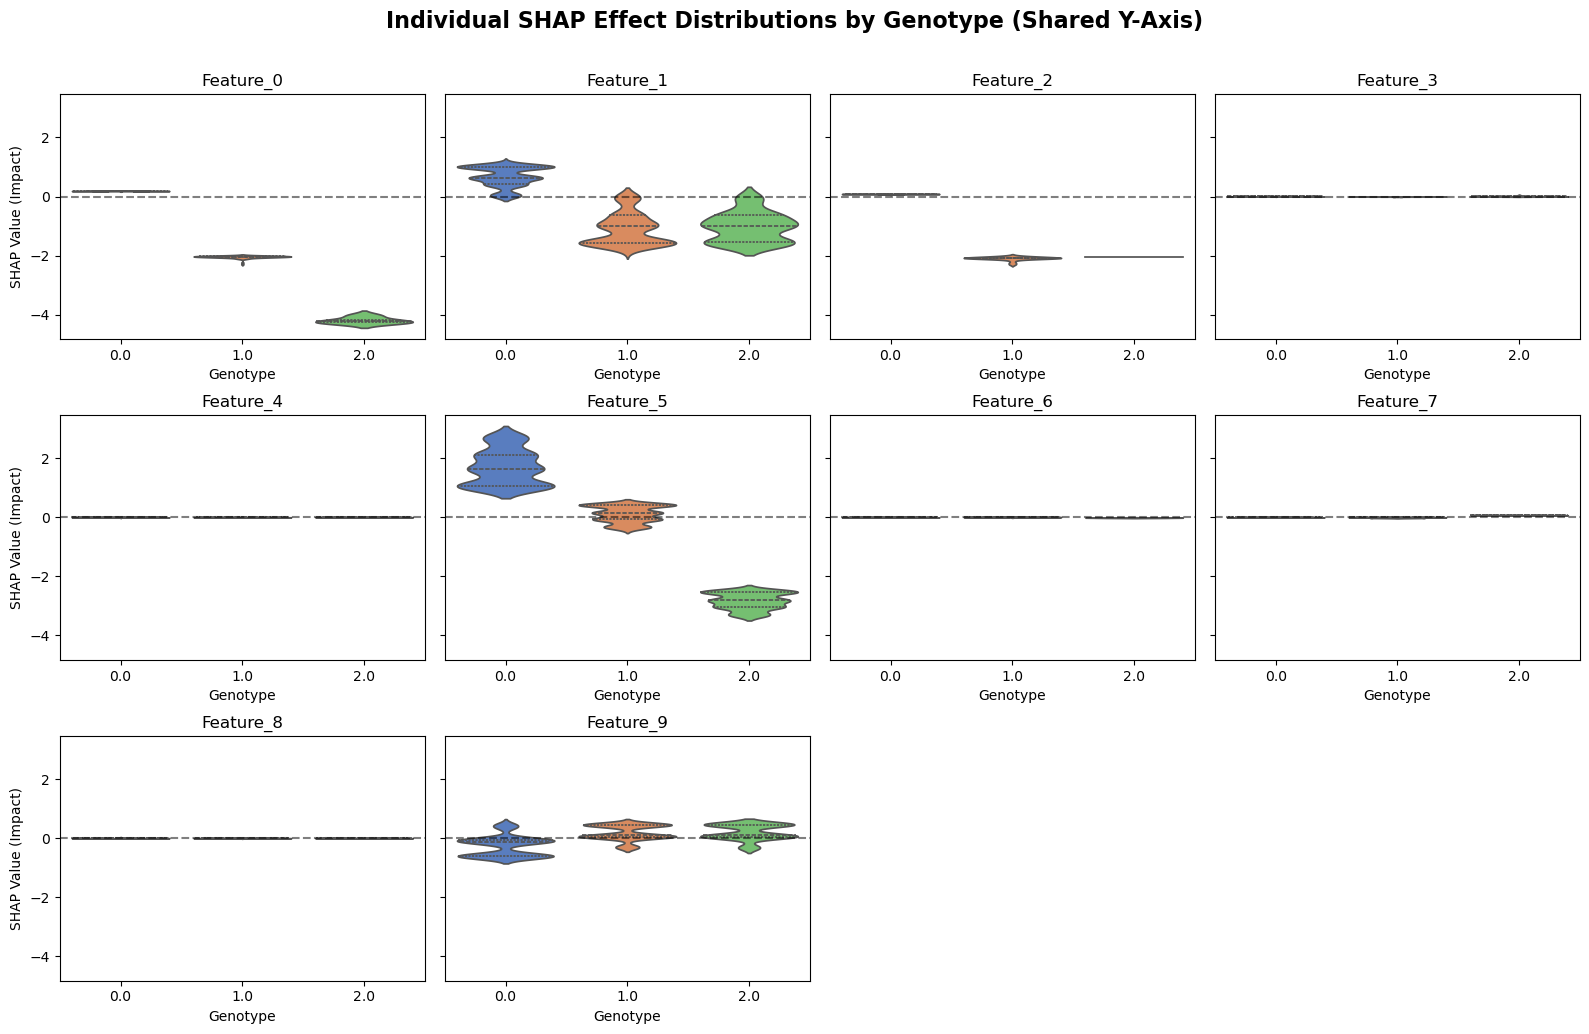

In [17]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


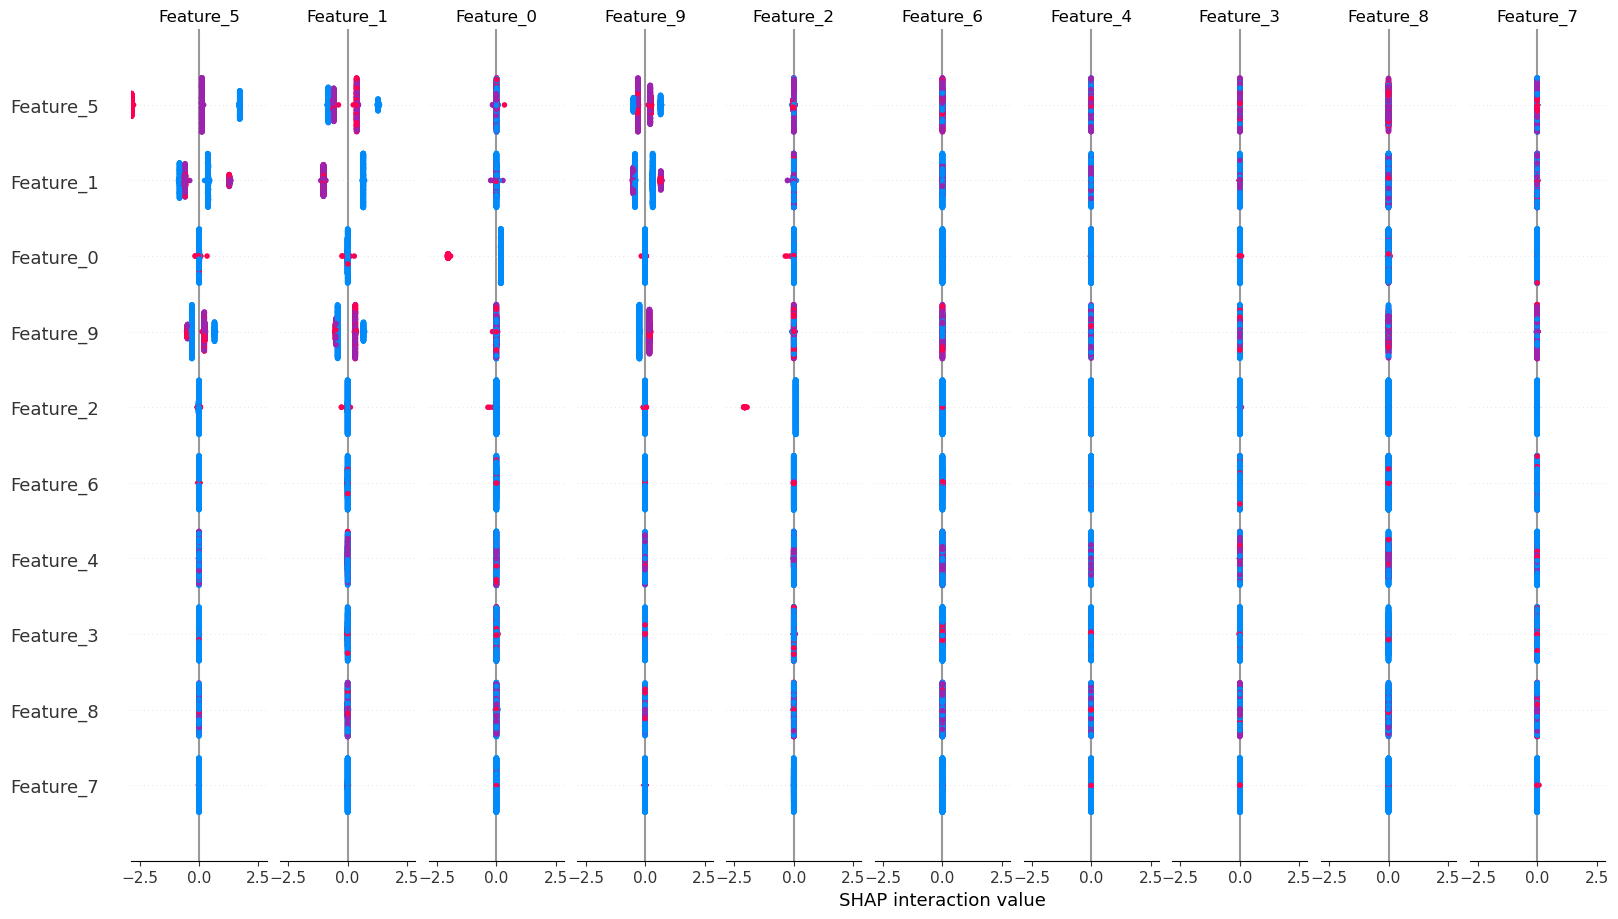


Strongest Interaction found by SHAP: Feature_1 & Feature_5
Plotting pure interaction effect for Feature_1 and Feature_5...


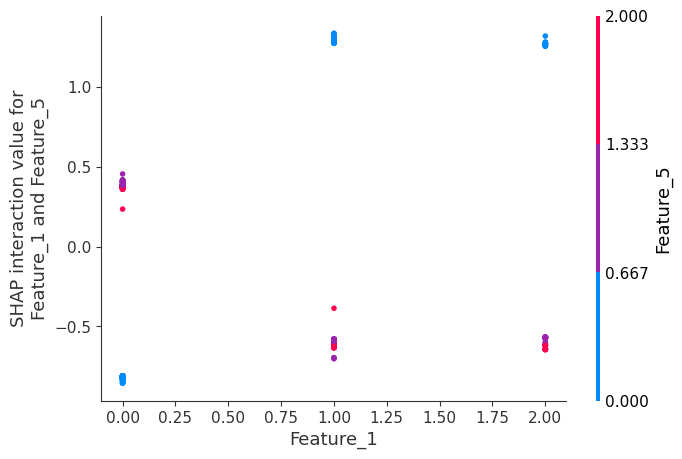


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_1 * Feature_5: 0.619834
  Feature_1 * Feature_9: 0.442307
  Feature_5 * Feature_9: 0.346188
  Feature_0 * Feature_5: 0.010550
  Feature_0 * Feature_1: 0.007646
  Feature_2 * Feature_5: 0.005616
  Feature_0 * Feature_9: 0.003558
  Feature_0 * Feature_2: 0.002773
  Feature_1 * Feature_2: 0.002344
  Feature_2 * Feature_9: 0.002106
-------------------------------------------------

Interaction Effects:
 {'Feature_1 * Feature_5': 0.619833767414093, 'Feature_1 * Feature_9': 0.44230666756629944, 'Feature_5 * Feature_9': 0.34618768095970154, 'Feature_0 * Feature_5': 0.010549528524279594, 'Feature_0 * Feature_1': 0.007646004669368267, 'Feature_2 * Feature_5': 0.005616133566945791, 'Feature_0 * Feature_9': 0.0035576336085796356, 'Feature_0 * Feature_2': 0.002773007145151496, 'Feature_1 * Feature_2': 0.002344157313928008, 'Feature_2 * Feature_9': 0.0021060125436633825, 'Feature_5 * Feature_6': 0.00186205

In [18]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [19]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_5              1.228338     0.0    288   1.711890  0.584775  1.025182  1.068414     1.639148  2.118755  2.719124
Feature_5              1.228338     1.0    497   0.112650  0.270200 -0.375887 -0.063763     0.161623  0.417249  0.458042
Feature_5              1.228338     2.0    215  -2.834039  0.271004 -3.308872 -3.029442    -2.810326 -2.524064 -2.478309
Feature_1              0.833030     0.0    602   0.673289  0.330817  0.032932  0.409684     0.637482  1.007325  1.105232
Feature_1              0.833030     1.0    304  -1.092755  0.524221 -1.770574 -1.561037    -0.991172 -0.637300 -0.033500
Feature_1              0.833030     2.0     94  -1.016091  0.487289 -1.599402 -1.548036    -0.983535 -0.629488 -0.064350
Feature_0              0.352559     0.0    916   0.188013  0.005069  0.164149  0.184387     0.18

## test for addition of hidden features

### make example data 3

In [20]:
# 1. Generate Data
X, X_hidden, y, visible_features, hidden_features = generate_synthetic_data_with_hidden_features(
    num_inputs=10, 
    num_samples=5000, 
    probability_range=(0.01, 0.49),
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-3, 3), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-3, 3), 
    noise_std=0.1, 
    hidden_in_linear=True,           
    hidden_in_interactions=True
)
# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With HIDDEN Features) ---
y = 
  (2.91 * Feature_9 [dominant]) + 
  (-2.78 * Feature_3 [recessive]) + 
  (-2.77 * Hidden_0 [recessive]) + 
  (2.59 * Hidden_1 [recessive]) + 
  (2.14 * Feature_7 [recessive]) + 
  (-2.66 * (Feature_2, Feature_3) [dominant_epistasis]) + 
  (-2.38 * (Feature_5, Hidden_0) [recessive_epistasis]) + 
  (-1.56 * (Feature_1, Feature_4) [xor_interference]) 
  + Noise(0, 0.1)



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     275.4
Date:                Sun, 12 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:47:23   Log-Likelihood:                -6666.0
No. Observations:                4000   AIC:                         1.335e+04
Df Residuals:                    3989   BIC:                         1.342e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

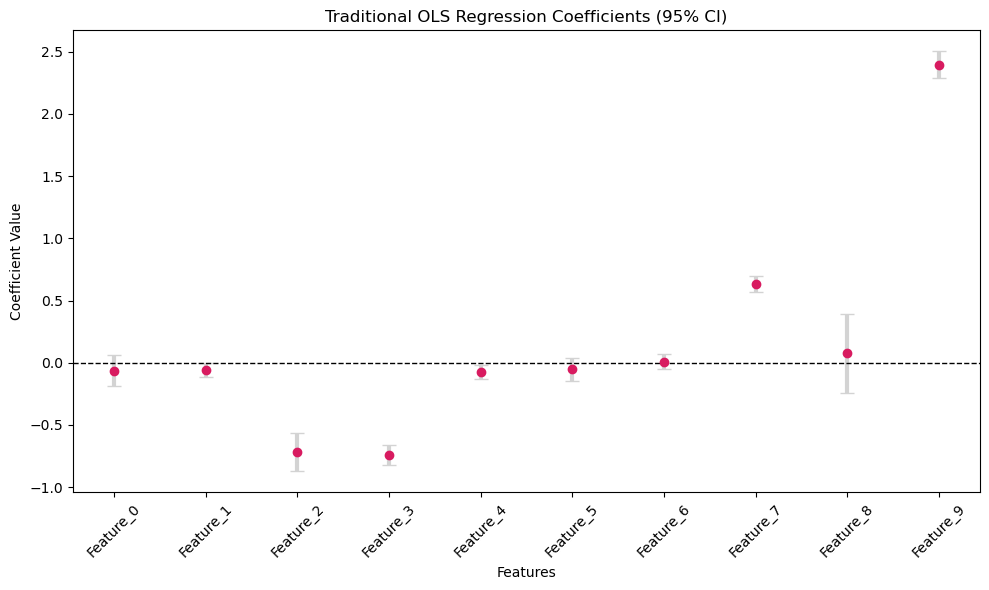

OLS Significant Features: {'Feature_9': {'pvalue': 0.0, 'coefficient': 2.397484919223531}, 'Feature_7': {'pvalue': 9.202908858099422e-82, 'coefficient': 0.6319077220993291}, 'Feature_3': {'pvalue': 1.7159222161548276e-69, 'coefficient': -0.7436498038526567}, 'Feature_2': {'pvalue': 2.180630505122925e-19, 'coefficient': -0.7180269298155134}, 'Feature_4': {'pvalue': 0.010020226814176218, 'coefficient': -0.07477224286457086}, 'Feature_1': {'pvalue': 0.03491615886191649, 'coefficient': -0.06095934382644472}}


In [21]:

# 2. Traditional Baseline (OLS)
ols_model, significant_features = perform_traditional_regression(X_train, y_train)

print("OLS Significant Features:", significant_features)


### make a simple xgboost model for test 3

In [22]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost)
model = xgb.XGBRegressor(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1 Evaluation & XGBoost Importances
evaluate_xgb_model(model, X_test_cat, y_test)

--- XGBoost Performance (Testing) ---
R2 Score: 0.7665
MSE: 0.6379



### look at XGBoost Native Importances

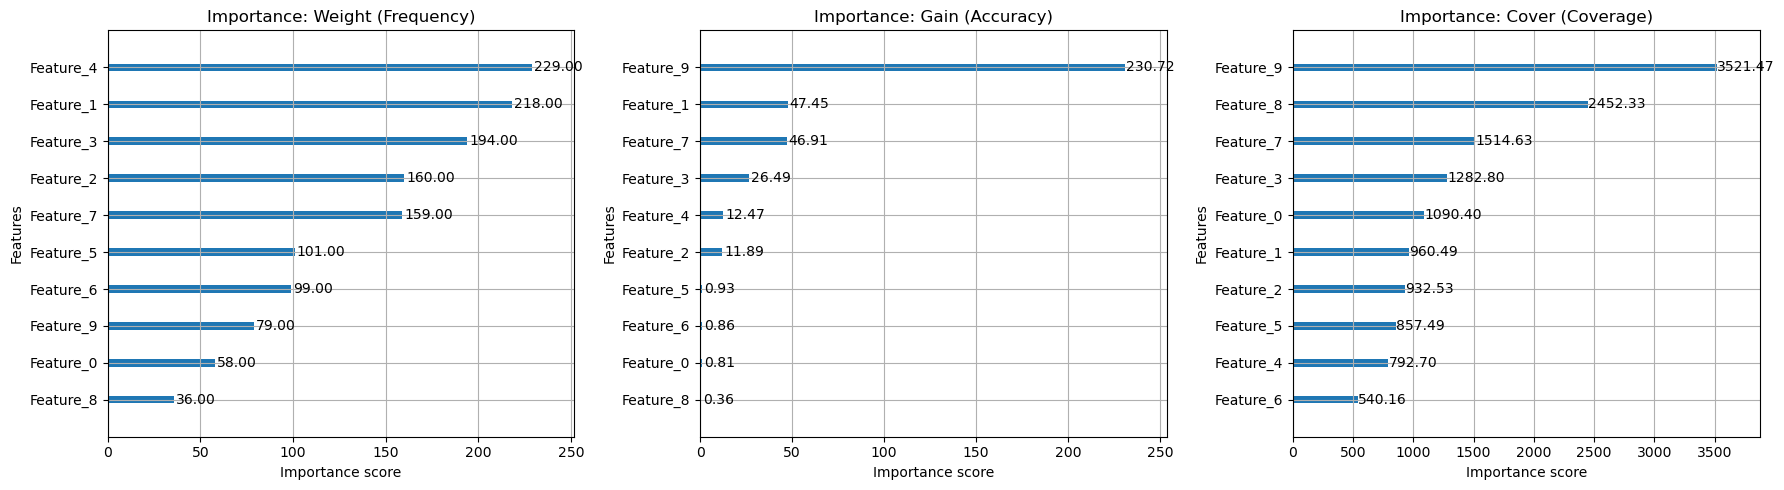

XGBoost Weight Importance: {'Feature_0': 58.0, 'Feature_1': 218.0, 'Feature_2': 160.0, 'Feature_3': 194.0, 'Feature_4': 229.0, 'Feature_5': 101.0, 'Feature_6': 99.0, 'Feature_7': 159.0, 'Feature_8': 36.0, 'Feature_9': 79.0}
XGBoost Gain Importance: {'Feature_0': 0.8147727847099304, 'Feature_1': 47.451011657714844, 'Feature_2': 11.893110275268555, 'Feature_3': 26.493928909301758, 'Feature_4': 12.472789764404297, 'Feature_5': 0.934319019317627, 'Feature_6': 0.864818274974823, 'Feature_7': 46.90612030029297, 'Feature_8': 0.3605698347091675, 'Feature_9': 230.7173614501953}
XGBoost Cover Importance: {'Feature_0': 1090.3966064453125, 'Feature_1': 960.4862670898438, 'Feature_2': 932.53125, 'Feature_3': 1282.7989501953125, 'Feature_4': 792.7030639648438, 'Feature_5': 857.4851684570312, 'Feature_6': 540.16162109375, 'Feature_7': 1514.62890625, 'Feature_8': 2452.333251953125, 'Feature_9': 3521.46826171875}


In [23]:

# 5.2 XGBoost Importances
weight_importance, gain_importance, cover_importance = plot_all_xgb_importances(model)

print("XGBoost Weight Importance:", weight_importance)
print("XGBoost Gain Importance:", gain_importance)
print("XGBoost Cover Importance:", cover_importance)


### try to use SHAP to find the influencing inputs

In [24]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

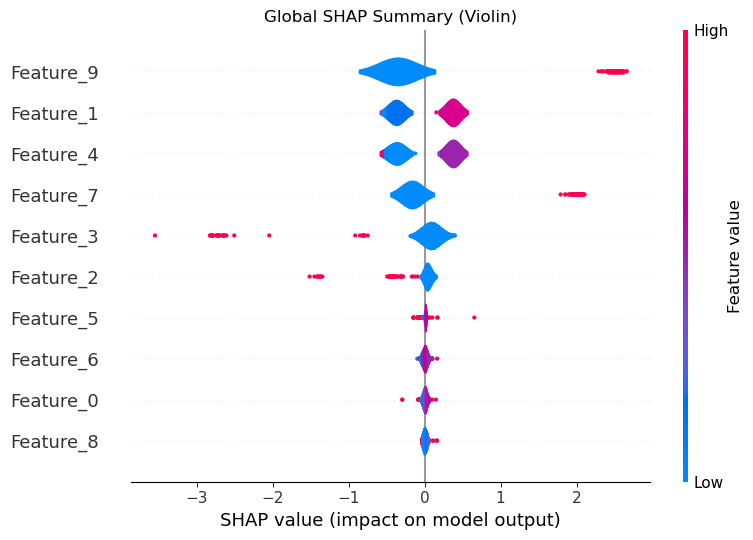

In [25]:

# Global SHAP Violin Summary
plot_shap_summary_violin(shap_values, X_test_cat)


Generating SHAP violin grid for all features...


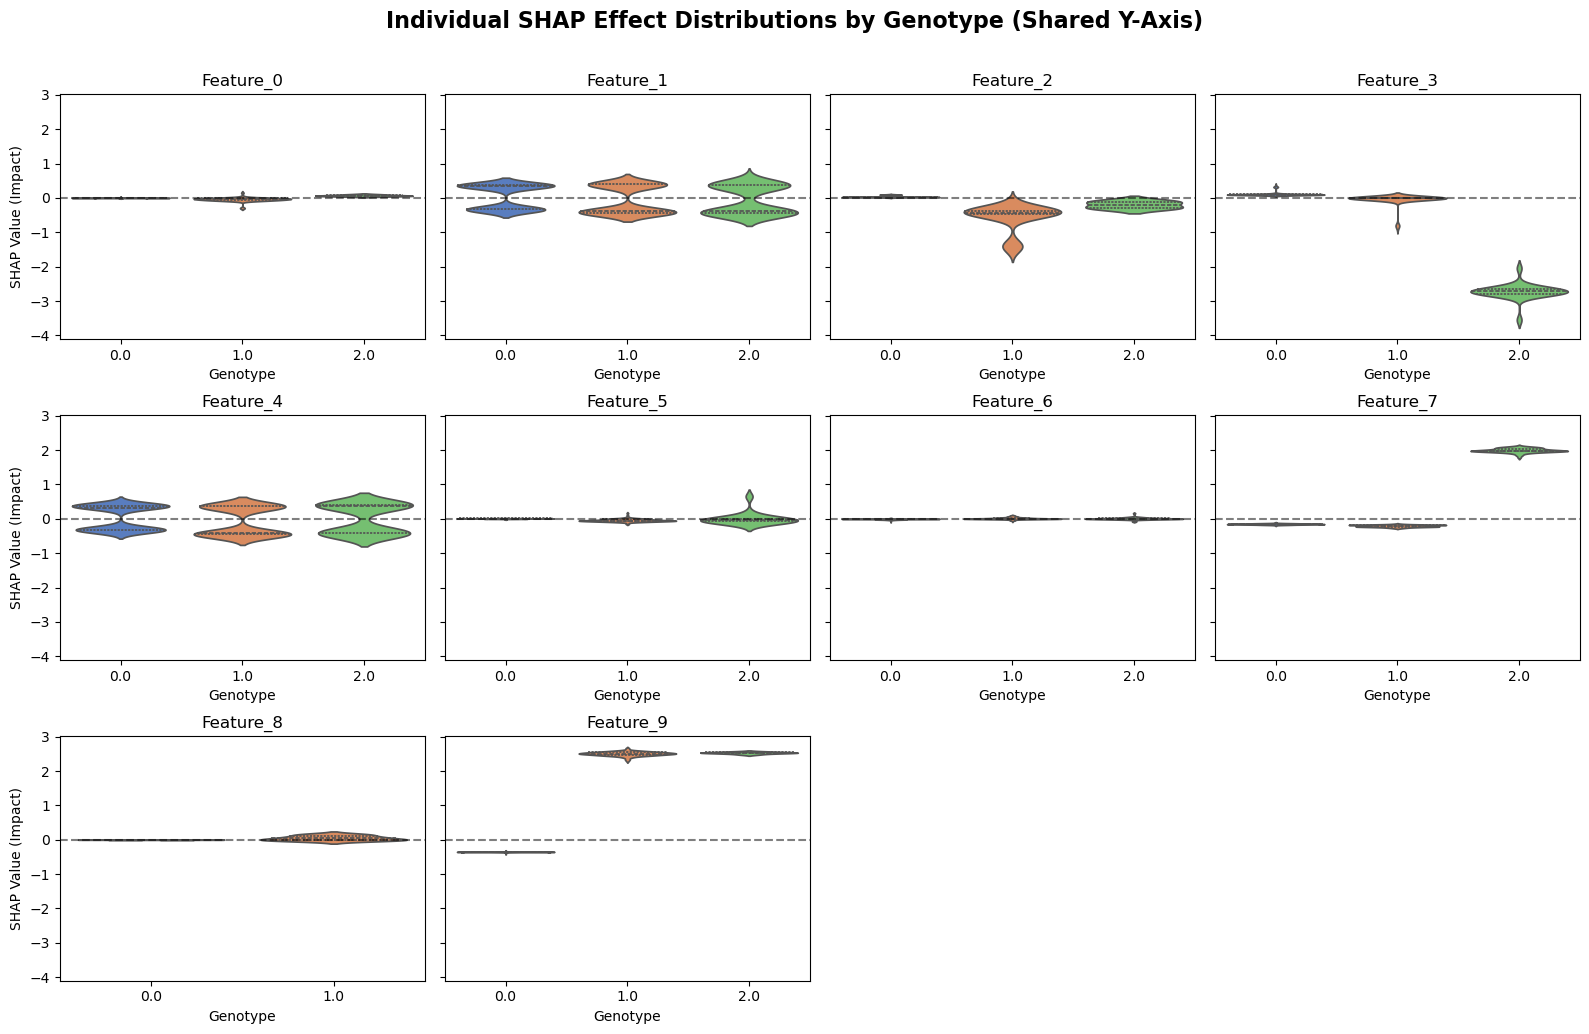

In [26]:

# 7. Individual Feature Violin Plots (All in one grid)
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


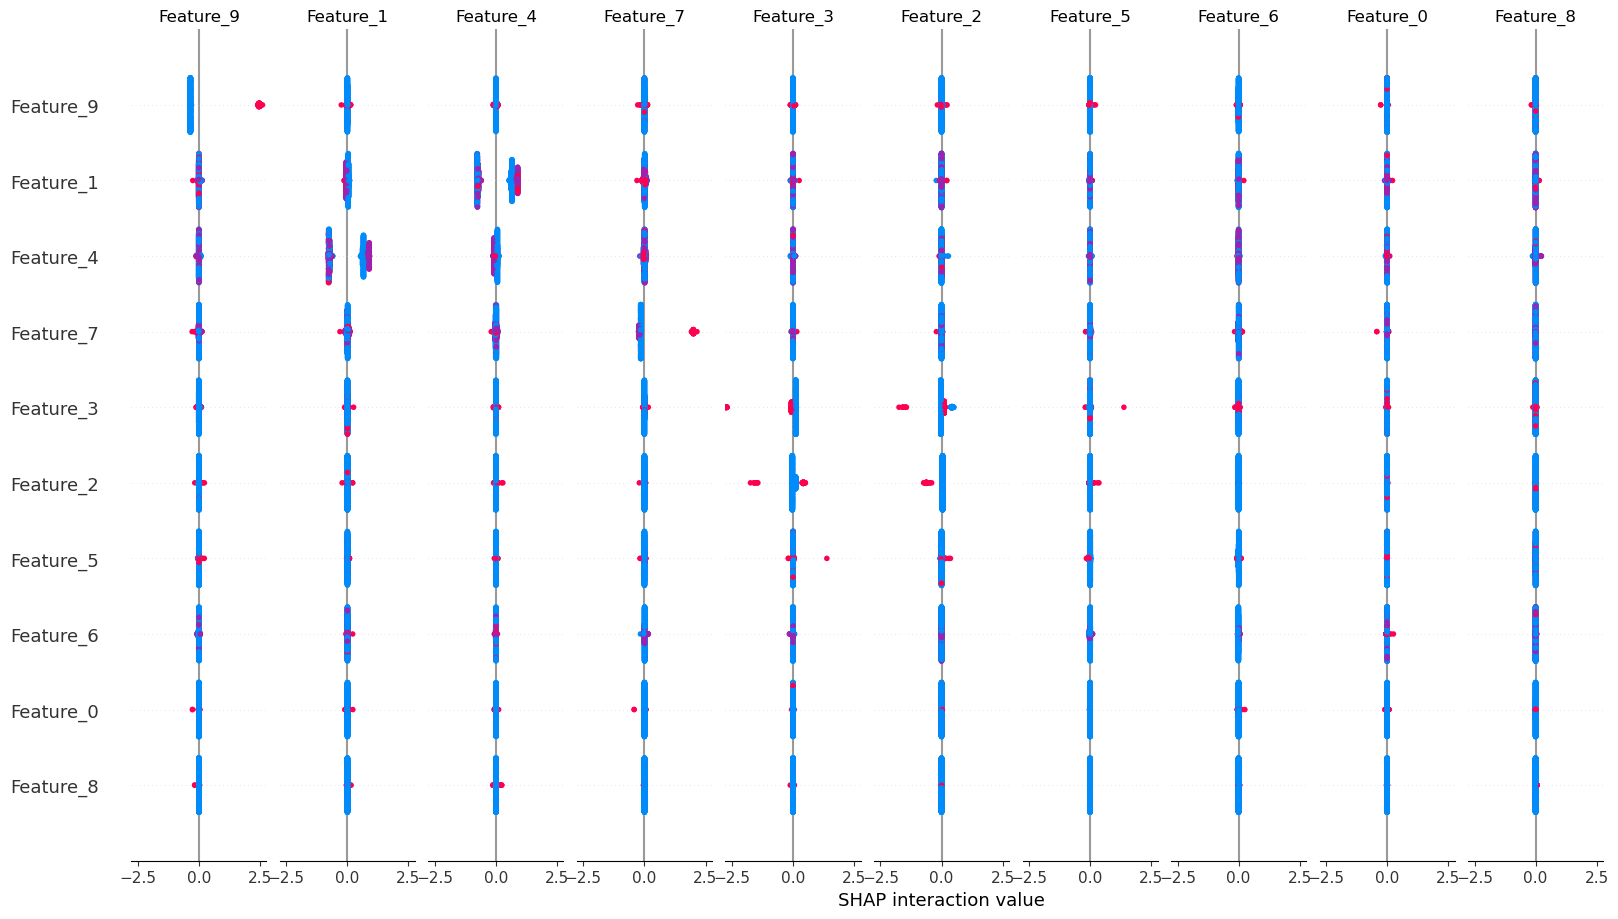


Strongest Interaction found by SHAP: Feature_1 & Feature_4
Plotting pure interaction effect for Feature_1 and Feature_4...


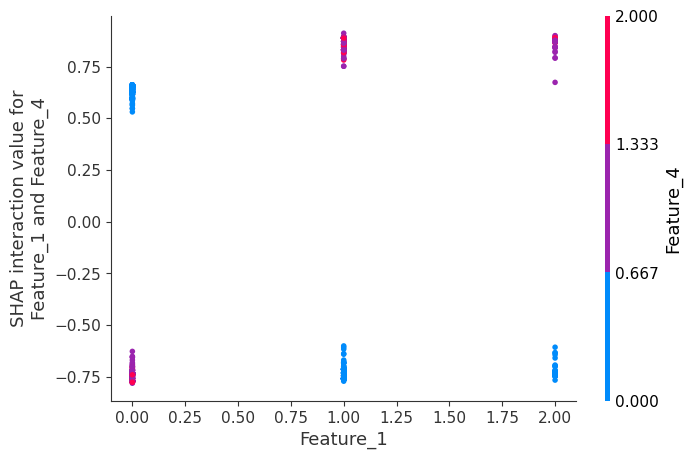


--- SHAP Interaction Feature Importance Ranking ---
Top 10 Strongest Interactions:
  Feature_1 * Feature_4: 0.738143
  Feature_2 * Feature_3: 0.077592
  Feature_1 * Feature_7: 0.022128
  Feature_4 * Feature_7: 0.019254
  Feature_5 * Feature_6: 0.012651
  Feature_3 * Feature_9: 0.011409
  Feature_6 * Feature_7: 0.010712
  Feature_1 * Feature_9: 0.010069
  Feature_4 * Feature_9: 0.009951
  Feature_7 * Feature_9: 0.008762
-------------------------------------------------

Interaction Effects:
 {'Feature_1 * Feature_4': 0.7381430864334106, 'Feature_2 * Feature_3': 0.07759179919958115, 'Feature_1 * Feature_7': 0.022127684205770493, 'Feature_4 * Feature_7': 0.01925411820411682, 'Feature_5 * Feature_6': 0.012650786899030209, 'Feature_3 * Feature_9': 0.01140948198735714, 'Feature_6 * Feature_7': 0.010712339542806149, 'Feature_1 * Feature_9': 0.010068639181554317, 'Feature_4 * Feature_9': 0.009951096959412098, 'Feature_7 * Feature_9': 0.008761659264564514, 'Feature_3 * Feature_7': 0.0073675471

In [27]:

# 8. Deep Dive: Interactions
sorted_interactions = analyze_shap_interactions(model, X_test_cat, visible_features)

print("Interaction Effects:\n", sorted_interactions)


#### SHAP summry

In [28]:

# Print numerical ranking and save the list!
importance_df = print_feature_importance(shap_values, X_test_cat)

print("Ranked Features by SHAP Importance:", importance_df)


--- SHAP Feature Distribution Statistics by Genotype ---
  Feature  Global_Mean_Abs_SHAP  Option  Count  Mean_SHAP  Std_SHAP  Min_SHAP  25%_SHAP  Median_SHAP  75%_SHAP  Max_SHAP
Feature_9              0.654078     0.0    861  -0.355170  0.007370 -0.422931 -0.359353    -0.354716 -0.351129 -0.310417
Feature_9              0.654078     1.0    128   2.503534  0.058218  2.286614  2.475291     2.502740  2.540966  2.657676
Feature_9              0.654078     2.0     11   2.529522  0.025919  2.476766  2.520446     2.531278  2.542397  2.565892
Feature_1              0.372917     0.0    522   0.049243  0.345342 -0.372483 -0.331683     0.337772  0.368481  0.392201
Feature_1              0.372917     1.0    369  -0.052982  0.399068 -0.442165 -0.426645    -0.382028  0.393630  0.453672
Feature_1              0.372917     2.0    109  -0.058184  0.398899 -0.499732 -0.429259    -0.367205  0.372006  0.549826
Feature_4              0.372069     0.0    552   0.044129  0.344946 -0.380033 -0.319515     0.32